In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import os
import json
import glob
import re
from joblib import Parallel, delayed

from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon

from project_original_files.MatrixVectorizer import MatrixVectorizer

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
base_path = "/vol/bitbucket/mf1025/RefineU/"
results_json_path = os.path.join(base_path, "evaluation_results.json")
NUM_ROI = 268
VEC_LEN = NUM_ROI * (NUM_ROI - 1) // 2  # 35778

# Maps config path → display name (optional pretty labels for plots)
rename_dict = {
    # "defend/linear_alg"
}

ignore_list = [
    "RefineU/Betweeness-NonGated-UnetLoss0",
    "RefineU/"
]

In [3]:
# ── Metric computation (parallelized) ────────────────────────────────────────

N_JOBS = -1  # use all CPU cores; set to e.g. 8 to limit
BC_K = 80    # approximate betweenness with k pivot nodes (None = exact)


def _centralities_single(pred_mat: np.ndarray, gt_mat: np.ndarray) -> dict:
    """Compute per-sample centrality MAEs/MSEs. Runs in a worker process."""
    pred_g = nx.from_numpy_array(pred_mat, edge_attr="weight")
    gt_g   = nx.from_numpy_array(gt_mat,   edge_attr="weight")

    # Betweenness (approximate if BC_K is set)
    kw = dict(weight="weight")
    if BC_K is not None:
        kw["k"] = BC_K
    pred_bc = list(nx.betweenness_centrality(pred_g, **kw).values())
    gt_bc   = list(nx.betweenness_centrality(gt_g,   **kw).values())

    # Eigenvector (with fallback)
    def _ec(g):
        try:
            return list(nx.eigenvector_centrality(g, weight="weight").values())
        except nx.PowerIterationFailedConvergence:
            return list(nx.eigenvector_centrality(g, weight="weight", max_iter=5000).values())
    pred_ec = _ec(pred_g)
    gt_ec   = _ec(gt_g)

    # PageRank
    pred_pc = list(nx.pagerank(pred_g, weight="weight").values())
    gt_pc   = list(nx.pagerank(gt_g,   weight="weight").values())

    # Closeness (unweighted / hop-based – values in (0,1])
    pred_cc = list(nx.closeness_centrality(pred_g).values())
    gt_cc   = list(nx.closeness_centrality(gt_g).values())

    # Degree (no weights – trivial, but kept via networkx for consistency)
    pred_dc = list(nx.degree_centrality(pred_g).values())
    gt_dc   = list(nx.degree_centrality(gt_g).values())

    return {
        "mae_bc": mean_absolute_error(gt_bc, pred_bc),
        "mae_ec": mean_absolute_error(gt_ec, pred_ec),
        "mae_pc": mean_absolute_error(gt_pc, pred_pc),
        "mse_cc": mean_squared_error(gt_cc, pred_cc),
        "mse_dc": mean_squared_error(gt_dc, pred_dc),
        "pred_1d": MatrixVectorizer.vectorize(pred_mat),
        "gt_1d":   MatrixVectorizer.vectorize(gt_mat),
    }


def compute_full_evaluation(pred_matrices: np.ndarray, gt_matrices: np.ndarray) -> dict:
    """
    Compute 8 evaluation metrics – parallelized across samples.
    Returns dict with keys: MAE, PCC, JSD, BC, EC, PC, CC, DC
    """
    n = len(pred_matrices)
    print(f"(parallel, {N_JOBS} jobs, BC_K={BC_K})", end=" ", flush=True)

    results = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(_centralities_single)(pred_matrices[i], gt_matrices[i])
        for i in range(n)
    )

    pred_1d = np.concatenate([r["pred_1d"] for r in results])
    gt_1d   = np.concatenate([r["gt_1d"]   for r in results])

    return {
        "MAE": float(mean_absolute_error(gt_1d, pred_1d)),
        "PCC": float(pearsonr(pred_1d, gt_1d)[0]),
        "JSD": float(jensenshannon(pred_1d, gt_1d)),
        "BC":  float(np.mean([r["mae_bc"] for r in results])),
        "EC":  float(np.mean([r["mae_ec"] for r in results])),
        "PC":  float(np.mean([r["mae_pc"] for r in results])),
        "CC":  float(np.mean([r["mse_cc"] for r in results])),
        "DC":  float(np.mean([r["mse_dc"] for r in results])),
    }

In [4]:
# ── Discovery: find all configuration directories ───────────────────────────

def discover_configs(base: str) -> list[str]:
    """
    Recursively find leaf directories that contain only CSV files (no subdirs).
    Returns list of relative paths from *base*.
    """
    configs = []
    for root, dirs, files in os.walk(base):
        # leaf directory: no sub-directories and at least one csv
        if not dirs and any(f.endswith(".csv") for f in files):
            configs.append(os.path.relpath(root, base))
    return sorted(configs)


def load_fold(config_dir: str, fold: int):
    """
    Load predictions and ground-truth matrices for a single fold.
    Returns (pred_matrices, gt_matrices) each of shape (N, NUM_ROI, NUM_ROI).
    """
    pred_path = os.path.join(config_dir, f"predictions_fold_{fold}.csv")
    gt_path = os.path.join(config_dir, f"groundtruth_fold_{fold}.csv")
    if not os.path.isfile(pred_path) or not os.path.isfile(gt_path):
        return None, None

    pred_df = pd.read_csv(pred_path)
    gt_df = pd.read_csv(gt_path)

    pred_vec = pred_df["Predicted"].values
    gt_vec = gt_df["Predicted"].values

    num_samples = len(pred_vec) // VEC_LEN
    assert len(pred_vec) == num_samples * VEC_LEN, (
        f"Prediction vector length {len(pred_vec)} not divisible by {VEC_LEN}"
    )

    pred_matrices = np.stack([
        MatrixVectorizer.anti_vectorize(pred_vec[i * VEC_LEN:(i + 1) * VEC_LEN], NUM_ROI)
        for i in range(num_samples)
    ])
    gt_matrices = np.stack([
        MatrixVectorizer.anti_vectorize(gt_vec[i * VEC_LEN:(i + 1) * VEC_LEN], NUM_ROI)
        for i in range(num_samples)
    ])
    return pred_matrices, gt_matrices


print(f"Discovered configs: {discover_configs(base_path)}")

Discovered configs: ['RefineU/Identity-Gated-UnetLoss0', 'defend/bi_mp', 'defend/linear_algebraic', 'gsrn']


In [5]:
# ── Run evaluation (or load cached results) ─────────────────────────────────

def run_all_evaluations(base: str, json_path: str, force: bool = False) -> dict:
    """
    For every config, evaluate each fold. Results are cached in a JSON file.
    Structure:  { config_name: { "fold_1": {metrics}, "fold_2": {...}, ... } }
    Saves incrementally after each config so partial results survive crashes.
    """
    # Load existing results (resume-friendly)
    if os.path.isfile(json_path):
        with open(json_path) as f:
            results = json.load(f)
    else:
        results = {}

    configs = discover_configs(base)

    if not force:
        remaining = [c for c in configs if c not in results]
        if not remaining:
            print(f"All {len(configs)} configs already cached in {json_path}")
            return results
        print(f"{len(results)}/{len(configs)} configs cached, {len(remaining)} remaining")
    else:
        remaining = configs

    for cfg in remaining:
        cfg_dir = os.path.join(base, cfg)
        # auto-detect folds present
        fold_files = sorted(glob.glob(os.path.join(cfg_dir, "predictions_fold_*.csv")))
        fold_nums = [
            int(re.search(r"fold_(\d+)", os.path.basename(f)).group(1))
            for f in fold_files
        ]
        print(f"  Config '{cfg}' — folds {fold_nums}")
        cfg_results = {}
        for fold in fold_nums:
            pred, gt = load_fold(cfg_dir, fold)
            if pred is None:
                print(f"    ⚠ fold {fold} missing, skipping")
                continue
            print(f"    Evaluating fold {fold} ({pred.shape[0]} samples)…", end=" ", flush=True)
            metrics = compute_full_evaluation(pred, gt)
            cfg_results[f"fold_{fold}"] = metrics
            print("done")
        results[cfg] = cfg_results

        # Save after each config so progress is not lost
        with open(json_path, "w") as f:
            json.dump(results, f, indent=2)
        print(f"    ✓ saved ({len(results)}/{len(configs)} configs)")

    print(f"\nAll done — {len(results)} configs in {json_path}")
    return results


all_results = run_all_evaluations(base_path, results_json_path, force=False)

0/4 configs cached, 4 remaining
  Config 'RefineU/Identity-Gated-UnetLoss0' — folds [1, 2, 3]
    Evaluating fold 1 (56 samples)… (parallel, -1 jobs, BC_K=80) done
    Evaluating fold 2 (56 samples)… (parallel, -1 jobs, BC_K=80) done
    Evaluating fold 3 (55 samples)… (parallel, -1 jobs, BC_K=80) done
    ✓ saved (1/4 configs)
  Config 'defend/bi_mp' — folds [1, 2, 3]
    Evaluating fold 1 (56 samples)… (parallel, -1 jobs, BC_K=80) done
    Evaluating fold 2 (56 samples)… (parallel, -1 jobs, BC_K=80) done
    Evaluating fold 3 (55 samples)… (parallel, -1 jobs, BC_K=80) done
    ✓ saved (2/4 configs)
  Config 'defend/linear_algebraic' — folds [1, 2, 3]
    Evaluating fold 1 (56 samples)… (parallel, -1 jobs, BC_K=80) done
    Evaluating fold 2 (56 samples)… (parallel, -1 jobs, BC_K=80) done
    Evaluating fold 3 (55 samples)… (parallel, -1 jobs, BC_K=80) done
    ✓ saved (3/4 configs)
  Config 'gsrn' — folds [1, 2, 3]
    Evaluating fold 1 (56 samples)… (parallel, -1 jobs, BC_K=80) done

In [6]:
# ── Build tidy DataFrame for plotting ────────────────────────────────────────

METRIC_NAMES = ["MAE", "PCC", "JSD", "BC", "EC", "PC", "CC", "DC"]
METRIC_LABELS = {
    "MAE": "MAE",
    "PCC": "PCC",
    "JSD": "JSD",
    "BC":  "MAE BC",
    "EC":  "MAE EC",
    "PC":  "MAE PC",
    "CC":  "MSE CC",
    "DC":  "MSE CC",
}


def _display_name(cfg_name: str) -> str:
    return rename_dict.get(cfg_name, cfg_name)


def build_dataframe(results: dict) -> pd.DataFrame:
    """
    Convert nested results dict into a long-form DataFrame with columns:
        config, fold, metric, value
    """
    rows = []
    for cfg, folds in results.items():
        for fold_key, metrics in folds.items():
            fold_num = int(fold_key.split("_")[1])
            for m in METRIC_NAMES:
                rows.append({
                    "config": _display_name(cfg),
                    "fold": fold_num,
                    "fold_label": f"Fold {fold_num}",
                    "metric": m,
                    "value": metrics[m],
                })
    return pd.DataFrame(rows)


df = build_dataframe(all_results)
df.head(10)

,config,fold,fold_label,metric,value
0,RefineU/Identity-Gated-UnetLoss0,1,Fold 1,MAE,0.134125
1,RefineU/Identity-Gated-UnetLoss0,1,Fold 1,PCC,0.638052
2,RefineU/Identity-Gated-UnetLoss0,1,Fold 1,JSD,0.284527
3,RefineU/Identity-Gated-UnetLoss0,1,Fold 1,BC,0.019176
4,RefineU/Identity-Gated-UnetLoss0,1,Fold 1,EC,0.013638
5,RefineU/Identity-Gated-UnetLoss0,1,Fold 1,PC,0.000565
6,RefineU/Identity-Gated-UnetLoss0,1,Fold 1,CC,0.018568
7,RefineU/Identity-Gated-UnetLoss0,1,Fold 1,DC,0.037032
8,RefineU/Identity-Gated-UnetLoss0,2,Fold 2,MAE,0.143032
9,RefineU/Identity-Gated-UnetLoss0,2,Fold 2,PCC,0.609763


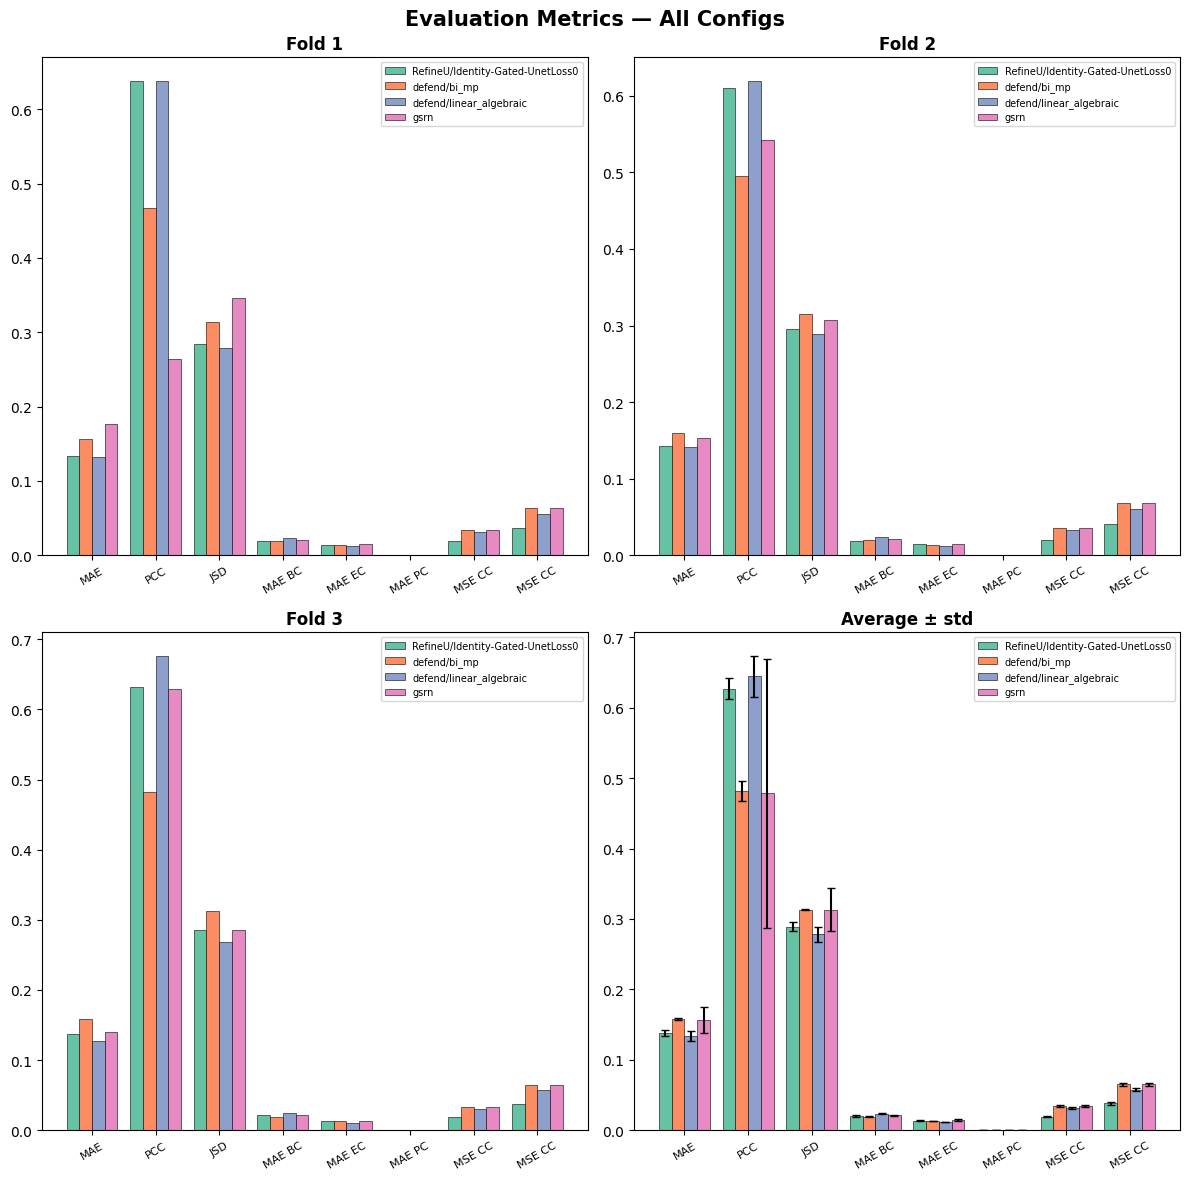

In [14]:
# ── Plotting ─────────────────────────────────────────────────────────────────

def plot_evaluation(df: pd.DataFrame, save_dir: str | None = None):
    """
    Single figure with 4 subplots (3 folds + 1 average).
    Each subplot: grouped bars – one group per metric, one bar per config.
    Average subplot uses error bars (mean ± std across folds).
    """
    folds = sorted(df["fold"].unique())
    configs = sorted(df["config"].unique())
    n_metrics = len(METRIC_NAMES)
    n_configs = len(configs)
    palette = sns.color_palette("Set2", n_colors=n_configs)

    bar_width = 0.8 / n_configs
    x_base = np.arange(n_metrics)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()  # [fold1, fold2, fold3, avg]

    # ── Per-fold subplots ──
    for idx, fold in enumerate(folds[:3]):
        ax = axes[idx]
        for j, cfg in enumerate(configs):
            vals = []
            for m in METRIC_NAMES:
                sub = df[(df["metric"] == m) & (df["fold"] == fold) & (df["config"] == cfg)]
                vals.append(sub["value"].values[0] if len(sub) else 0)
            offset = (j - n_configs / 2 + 0.5) * bar_width
            bars = ax.bar(x_base + offset, vals, width=bar_width,
                          color=palette[j], edgecolor="black", linewidth=0.4,
                          label=cfg)
        ax.set_xticks(x_base)
        ax.set_xticklabels([METRIC_LABELS[m] for m in METRIC_NAMES], rotation=30, ha="center", fontsize=8)
        ax.set_title(f"Fold {fold}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=7, loc="upper right")

    # ── Average subplot (mean ± std) ──
    ax_avg = axes[3]
    for j, cfg in enumerate(configs):
        means, stds = [], []
        for m in METRIC_NAMES:
            v = df[(df["metric"] == m) & (df["config"] == cfg)]["value"]
            means.append(v.mean())
            stds.append(v.std())
        offset = (j - n_configs / 2 + 0.5) * bar_width
        bars = ax_avg.bar(x_base + offset, means, yerr=stds, width=bar_width,
                          capsize=3, color=palette[j], edgecolor="black", linewidth=0.4,
                          label=cfg)
    ax_avg.set_xticks(x_base)
    ax_avg.set_xticklabels([METRIC_LABELS[m] for m in METRIC_NAMES], rotation=30, ha="center", fontsize=8)
    ax_avg.set_title("Average ± std", fontsize=12, fontweight="bold")
    ax_avg.legend(fontsize=7, loc="upper right")

    # Hide unused axes if fewer than 3 folds
    for i in range(len(folds), 3):
        axes[i].set_visible(False)

    fig.suptitle("Evaluation Metrics — All Configs", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 1.0])

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, "all_metrics.png"), dpi=300, bbox_inches="tight")
        # save as svg
        fig.savefig(os.path.join(save_dir, "all_metrics.svg"), dpi=300, bbox_inches="tight", format="svg")

    plt.show()


plot_evaluation(df, save_dir=os.path.join(base_path, "plots"))

In [8]:
# ── Summary table (mean ± std across folds) ──────────────────────────────────

summary_rows = []
for cfg in sorted(df["config"].unique()):
    row = {"Config": cfg}
    for m in METRIC_NAMES:
        vals = df[(df["config"] == cfg) & (df["metric"] == m)]["value"]
        row[METRIC_LABELS[m]] = f"{vals.mean():.4f} ± {vals.std():.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Config")
summary_df

,MAE,PCC,JSD,MAE BC,MAE EC,MAE PC,MSE CC
Config,,,,,,,
RefineU/Identity-Gated-UnetLoss0,0.1382 ± 0.0045,0.6268 ± 0.0150,0.2888 ± 0.0063,0.0200 ± 0.0016,0.0137 ± 0.0004,0.0006 ± 0.0000,0.0383 ± 0.0020
defend/bi_mp,0.1577 ± 0.0019,0.4819 ± 0.0142,0.3134 ± 0.0010,0.0192 ± 0.0005,0.0133 ± 0.0003,0.0006 ± 0.0000,0.0652 ± 0.0023
defend/linear_algebraic,0.1336 ± 0.0066,0.6445 ± 0.0290,0.2785 ± 0.0107,0.0234 ± 0.0007,0.0116 ± 0.0006,0.0005 ± 0.0000,0.0575 ± 0.0021
gsrn,0.1564 ± 0.0186,0.4785 ± 0.1911,0.3129 ± 0.0305,0.0209 ± 0.0008,0.0144 ± 0.0011,0.0006 ± 0.0000,0.0652 ± 0.0023
